# Transfer Learning on Cats vs Dogs Classification with HuggingFace Vision Transformer (ViT) 
## Hyperparameter Sweep using Weights & Biases sweep agent

### CIML Summer Institute
### UC San Diego

## Setup


This notebook demonstrates how to use HuggingFace Transformers for image classification. We'll use a pre-trained Vision Transformer (ViT) model and fine-tune it on the cats vs. dogs dataset.

We use the AutoModelForImageClassification class from Huggingface to define our model. It is a simple linear layer on top of a Google ViT model. The final output dimension is 2, corresponding to the two image classes (cat and dog) which are softmaxed to achieve the final probabilities.

We read in the weights from our feature classifiction task, but now we unfreeze more parameters and let the model further adapt to our classification task.

Base Model:
https://huggingface.co/google/vit-base-patch16-224-in21k

AutoModelForImageClassification: https://huggingface.co/docs/transformers/en/model_doc/auto#transformers.AutoModelForImageClassification

Logging:
In this notebook, we do a hyperparameter sweep using wandb to find optimal hyperparameters for the model.


In [1]:
import numpy as np
import torch
import os

# HuggingFace imports
from datasets import load_dataset
from transformers import DefaultDataCollator
from transformers import ViTImageProcessor, AutoModelForImageClassification
from transformers import TrainingArguments, Trainer
from transformers import pipeline
from transformers import EarlyStoppingCallback

# Image processing
from torchvision import transforms

# Evaluation
import evaluate
import wandb

# Silence wandb output
os.environ["WANDB_SILENT"] = "true"

from torch import nn

/opt/Miniforge3-25.9.1-0-Linux-x86_64/envs/ptl-cuda-12-1/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/Miniforge3-25.9.1-0-Linux-x86_64/envs/ptl-cuda-12-1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define Parameters

In [2]:
# Image dimensions
IMAGE_DIM = 224
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

# Training parameters
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_DELTA = 0.001
N_GPUS = torch.cuda.device_count()
N_CPUS = int(os.environ.get("SLURM_CPUS_ON_NODE", os.cpu_count()))

# W&B project for logging
WANDB_PROJECT = "cats-vs-dogs-single-gpu-finetuning"

# Set seeds for reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
 
# Data location
DATA_DIR = os.environ.get("CIML26_DATA_DIR") + "/catsVsDogs"

# Output directory for model checkpoints
OUTPUT_DIR = "vit_cats_dogs_model/finetune"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device} with {N_GPUS} GPUs and {N_CPUS} CPUs.")


Using device cuda with 1 GPUs and 4 CPUs.


In [3]:
!jupyter --version
print (torch.__version__)
!python --version

!nvidia-smi

Selected Jupyter core packages...
IPython          : 9.13.0
ipykernel        : 7.2.0
ipywidgets       : not installed
jupyter_client   : 8.8.0
jupyter_core     : 5.9.1
jupyter_server   : 2.18.2
jupyterlab       : 4.5.7
nbclient         : 0.10.4
nbconvert        : 7.17.1
nbformat         : 5.10.4
notebook         : not installed
qtconsole        : not installed
traitlets        : 5.15.0
2.5.1
Python 3.12.13
Tue Jun 23 11:30:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=====

## Load Data

In [4]:
# Load the dataset
data = load_dataset("imagefolder", data_dir=DATA_DIR)

# Print dataset information
print(f"Train dataset size: {len(data['train'])}")
print(f"Validation dataset size: {len(data['validation'])}")
print(f"Test dataset size: {len(data['test'])}")

Train dataset size: 2000
Validation dataset size: 400
Test dataset size: 400


## Define Image Transformations

We use PyTorch to define data augmentations and preprocessing transformations to our model. The augmentation adds randomized extra images to our dataset for finetuning, improving the training distribution. 

We also define a Huggingface ViTImageProcessor which uses predefined transformations. We will use it later for inference.

In [5]:
# Load the image processor
image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

# Define the transformations
preprocess_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_DIM, IMAGE_DIM)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]
)

data_augmentation_transform = transforms.Compose(
    [
        transforms.RandomAffine(degrees=0, shear=0.2),
        transforms.RandomResizedCrop(size=IMAGE_DIM, scale=(0.8, 1.2)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]
)

# Custom preprocessing function for HuggingFace datasets
def preprocess_val_test(example):
    """Preprocessing function for validation and test data"""
    image = example['image']
    image = preprocess_transform(image)
    return {'pixel_values': image, 'label': example['label']}

def preprocess_train(example):
    """Preprocessing function for training data with augmentation"""
    image = example['image']
    image = data_augmentation_transform(image)
    return {'pixel_values': image, 'label': example['label']}

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 20164.92it/s]


In [6]:
# Set seed for deterministic multiprocessing
from transformers import set_seed
set_seed(seed)

processed_data = {}

processed_data['train'] = data['train'].map(preprocess_train, remove_columns=['image'], num_proc=N_CPUS)
processed_data['validation'] = data['validation'].map(preprocess_val_test, remove_columns=['image'], num_proc=N_CPUS)
processed_data['test'] = data['test'].map(preprocess_val_test, remove_columns=['image'], num_proc=N_CPUS)

# Set format for PyTorch
for split in processed_data:
    processed_data[split].set_format(type='torch', columns=['pixel_values', 'label'])

In [7]:
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

data_collator = DefaultDataCollator()

## Set Up Model
Load the pre-trained ViT feature extraction checkpoint, freeze the backbone, and replace the classifier head with a configurable dropout + linear layer. Only the classifier head and the last encoder layer are trainable.

In [8]:
def build_model(dropout_rate):
    labels    = data['train'].features['label'].names
    id2label  = {i: label for i, label in enumerate(labels)}
    label2id  = {label: i for i, label in id2label.items()}

    model = AutoModelForImageClassification.from_pretrained(
        "vit_cats_dogs_model/feature_extraction_best_model",
        num_labels=len(labels),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,   # needed because we replace the head below
    )

    # Freeze all backbone weights
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier head with dropout + linear (sweep-configurable dropout)
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(768, 2),
    )

    # Unfreeze classifier head and last encoder layer
    for name, param in model.named_parameters():
        if name.startswith("classifier") or "encoder.layer.11" in name:
            param.requires_grad = True

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,} "
          f"({trainable_params/total_params:.2%})")

    return model

## Set Up Sweep Configuration for Wandb

In [9]:
sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "eval/accuracy",
        "goal": "maximize",
    },
    "parameters": {
        "optimizer": {
            "values": ["adam", "sgd"],
        },
        "learning_rate": {
            "distribution": "log_uniform_values",
            "min": 1e-5,
            "max": 1e-1,
        },
        "dropout_rate": {
            "distribution": "uniform",
            "min": 0.1,
            "max": 0.5,
        },
    },
}

In [10]:
def sweep_train():
    os.environ["WANDB_SILENT"] = "true"
    run = wandb.init(
        project=WANDB_PROJECT,
        entity=wandb.Api().default_entity,
        settings=wandb.Settings(silent=True)
    )
    cfg = run.config

    print(f"\n{'='*60}")
    print(f"Trial — optimizer: {cfg.optimizer} | "
          f"lr: {cfg.learning_rate:.2e} | dropout: {cfg.dropout_rate:.2f}")
    print(f"{'='*60}\n")

    model = build_model(cfg.dropout_rate)

    if cfg.optimizer == "adam":
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=cfg.learning_rate,
        )
    else:
        optimizer = torch.optim.SGD(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=cfg.learning_rate,
            momentum=0.9,
        )

    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        num_train_epochs=NUM_EPOCHS,
        learning_rate=cfg.learning_rate,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        fp16=True,
        dataloader_num_workers=N_CPUS,
        push_to_hub=False,
        report_to="wandb",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=processed_data['train'],
        eval_dataset=processed_data['validation'],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=EARLY_STOPPING_DELTA,
        )],
        optimizers=(optimizer, None),
    )

    trainer.train()
    trainer.save_model(f"vit_cats_dogs_model/run_{wandb.run.id}")
    wandb.finish()

## Run the sweep using the Wandb Agent

Open the project in the wandb ui to see the sweep

In [11]:
sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=wandb.Api().default_entity)
print(f"Sweep ID: {sweep_id}")
wandb.agent(sweep_id, function=sweep_train, count=5)

Create sweep with ID: a9uwgxhq
Sweep URL: https://wandb.ai/ucsd_sbks/cats-vs-dogs-single-gpu-finetuning/sweeps/a9uwgxhq
Sweep ID: a9uwgxhq


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.



Trial — optimizer: sgd | lr: 2.29e-03 | dropout: 0.23

Trainable parameters: 7,089,410 / 85,800,194 (8.26%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.503800,0.306739,0.992500
2,0.226900,0.156018,0.992500
3,0.135700,0.105387,0.992500
4,0.100000,0.081912,0.995000
5,0.081800,0.068911,0.995000
6,0.070700,0.060998,0.995000
7,0.063900,0.056013,0.995000


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


...


Trial — optimizer: sgd | lr: 3.15e-05 | dropout: 0.18

Trainable parameters: 7,089,410 / 85,800,194 (8.26%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.647600,0.638721,0.842500
2,0.639200,0.630017,0.860000
3,0.630400,0.622392,0.882500
4,0.623500,0.615876,0.895000
5,0.619000,0.610381,0.910000
6,0.613500,0.605880,0.920000
7,0.607800,0.602421,0.927500
8,0.606500,0.599961,0.932500
9,0.602900,0.598483,0.932500
10,0.603300,0.597966,0.932500


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.



Trial — optimizer: sgd | lr: 1.45e-04 | dropout: 0.17

Trainable parameters: 7,089,410 / 85,800,194 (8.26%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.634200,0.613643,0.907500
2,0.595400,0.574863,0.970000
3,0.560800,0.542394,0.985000
4,0.531200,0.516019,0.990000
5,0.510100,0.494822,0.990000
6,0.488900,0.478533,0.990000
7,0.476200,0.466420,0.990000


## Load Best Model
Retrieve the best model, load its saved weights, and initialize an inference pipeline using the best hyperparameters found.

In [12]:
api = wandb.Api()
entity = api.default_entity

# Accessing sweep through sweep_id 
sweep = api.sweep(f"{entity}/{WANDB_PROJECT}/{sweep_id}")
best_run = sweep.best_run()

# Saving best model
best_model_path = f"vit_cats_dogs_model/run_{best_run.id}"

print(f"Best run ID: {best_run.id}")
sweep_params = ["optimizer", "learning_rate", "dropout_rate"]
best_hparams = {k: best_run.config[k] for k in sweep_params}
print(f"Best hyperparameters: {best_hparams}")

from safetensors.torch import load_file

best_model = build_model(best_hparams["dropout_rate"])
state_dict = load_file(f"{best_model_path}/model.safetensors")
best_model.load_state_dict(state_dict)

# Then set up classifier pipeline
classifier = pipeline(
    "image-classification",
    model=best_model,
    image_processor=image_processor,
)

Best run ID: 830971gg
Best hyperparameters: {'optimizer': 'adam', 'learning_rate': 0.00011334250827511353, 'dropout_rate': 0.4892125105183014}


Device set to use cuda:0


Trainable parameters: 7,089,410 / 85,800,194 (8.26%)


## Perform Inference

In [13]:
def predict_image(image_path):
    from PIL import Image
    import matplotlib.pyplot as plt
    
    image  = Image.open(image_path)
    result = classifier(image)
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Prediction: {result[0]['label']} ({result[0]['score']:.2f})")
    plt.axis('off')
    plt.show()
    return result

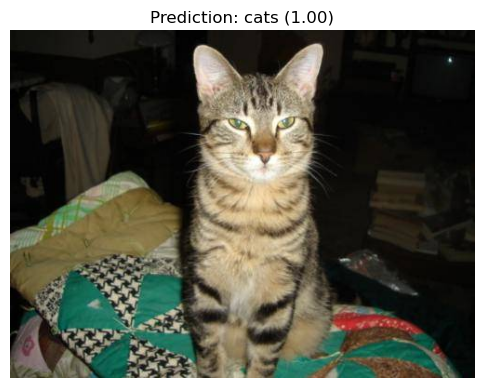

[{'label': 'cats', 'score': 0.9951924085617065},
 {'label': 'dogs', 'score': 0.004807642195373774}]

In [14]:
image_path = DATA_DIR + "/test/cats/cat.1070.jpg"
predict_image(image_path)

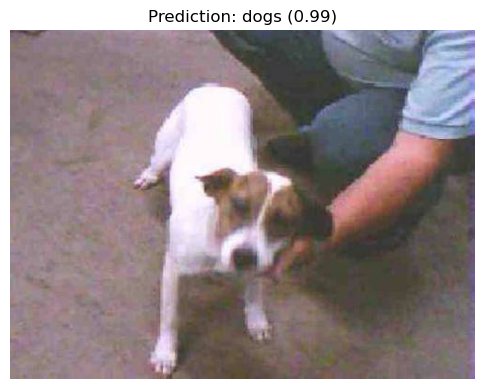

[{'label': 'dogs', 'score': 0.989737331867218},
 {'label': 'cats', 'score': 0.010262677446007729}]

In [15]:
image_path = DATA_DIR + "/test/dogs/dog.1233.jpg"
predict_image(image_path)

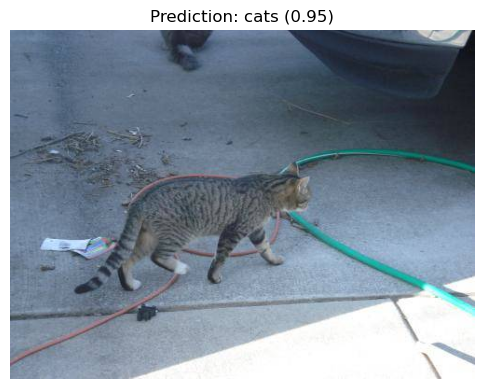

[{'label': 'cats', 'score': 0.9531921148300171},
 {'label': 'dogs', 'score': 0.04680785536766052}]

In [16]:
image_path = DATA_DIR + "/test/cats/cat.1080.jpg"
predict_image(image_path)

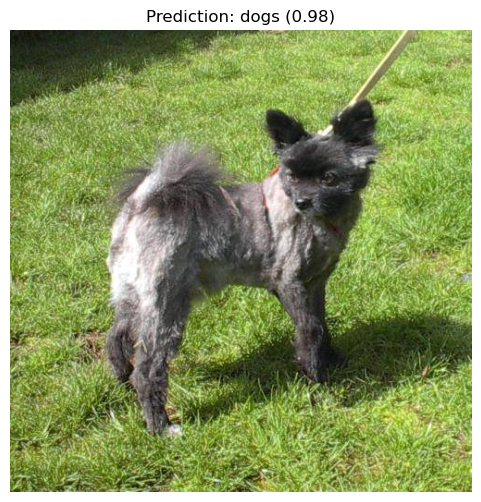

[{'label': 'dogs', 'score': 0.9838235378265381},
 {'label': 'cats', 'score': 0.016176488250494003}]

In [17]:
image_path = DATA_DIR + "/test/dogs/dog.1132.jpg"
predict_image(image_path)